In [50]:
import pandas as pd
import numpy as np
from matplotlib import pylab as plt
import sklearn

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Задание 1. 

Поработайте с датасетом про цены мобильных телефонов, обучите регрессию. 

In [51]:
data = pd.read_csv('Cellphone.csv')
data.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [52]:
data.isna().any()

Product_id      False
Price           False
Sale            False
weight          False
resoloution     False
ppi             False
cpu core        False
cpu freq        False
internal mem    False
ram             False
RearCam         False
Front_Cam       False
battery         False
thickness       False
dtype: bool

In [53]:
for i in data.columns:
    unique = data[i].unique()
    print(i, unique, type(data[i].unique()[0]))

Product_id [ 203  880   40   99  947  774 1103  289  605  622 1058 1120  187  315
  860  990  104  776   10 1145 1020 1339  662  575  907  162  974  739
  738  804   43 1248   93  563  577  218   56  198   14  857  937   66
 1221 1011 1026 1216  237  763  131 1062  841 1143  183 1080  827  133
  832  637   64   30  409  143  798  460 1327 1198 1112  696 1089  497
  301  377  701 1161   32 1137  851  826  290 1131 1206 1296  856] <class 'numpy.int64'>
Price [2357 1749 1916 1315 2137 1238 2580 2438 2006 2174 2744 1612 2258 2938
 2392 2977 1942 1390 1950 3316 2654 1421 2124 1777 2087 1843 2859 1989
 2685 1741 1347 3658 1984 2824 2746 2323 2044 1734 2276 3116 2571 1396
 2714 3005  791 3837 1646 1302 1831 1810 1511 2562 1522 2343  833 1676
 2858  754 2975 2880 3287 2054 2001  705 2491 2466 1357 2266 2445 2409
  628 2508 1921 3102 3055  614 4361 2536 3551 3211 3260] <class 'numpy.int64'>
Sale [  10   11   12   13   14   15   16   17   19   20   21   22   23   24
   25   26   30   31   32   3

Product_id


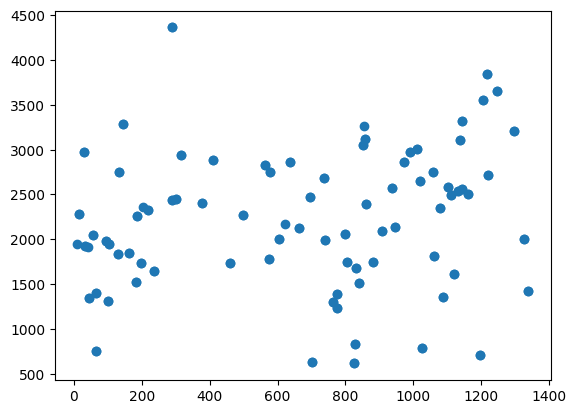

Sale


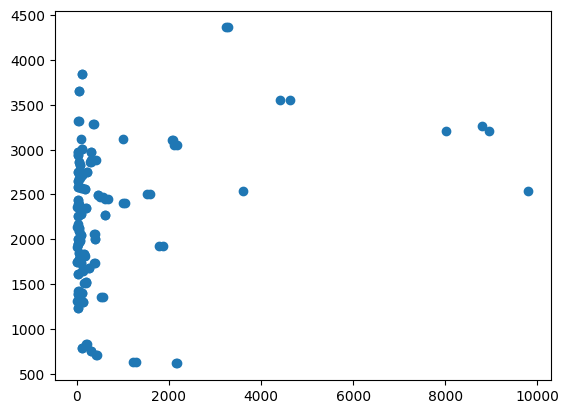

weight


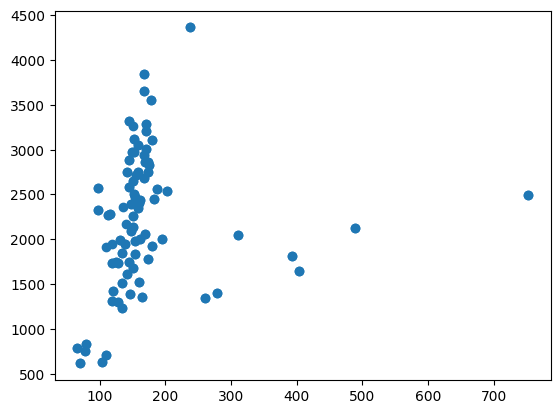

resoloution


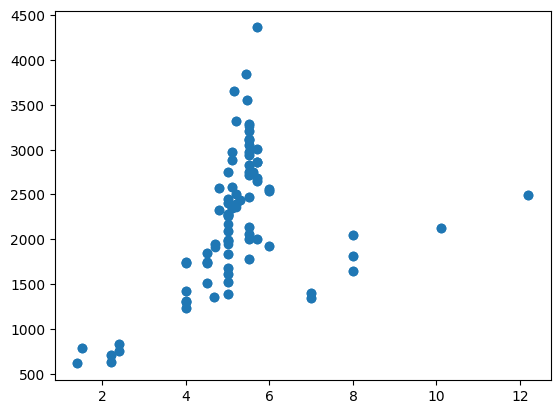

ppi


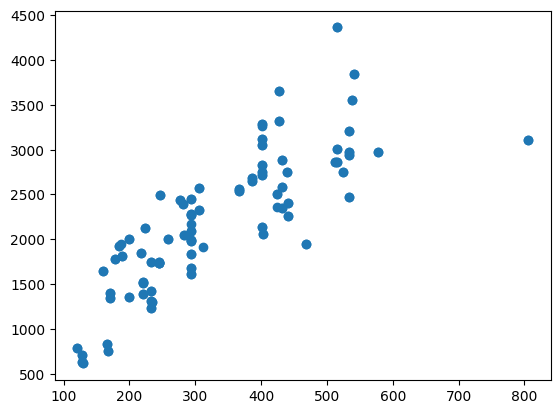

cpu core


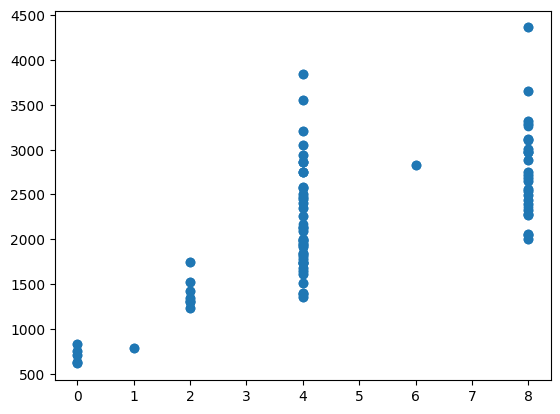

cpu freq


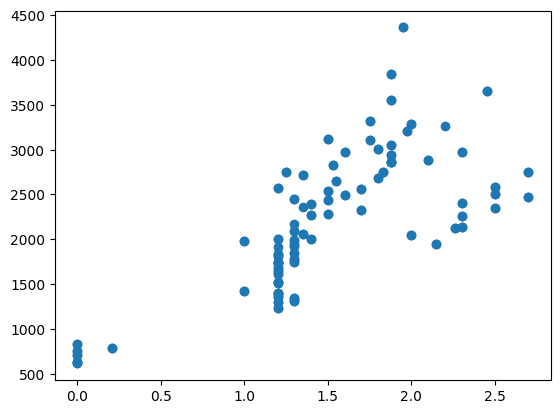

internal mem


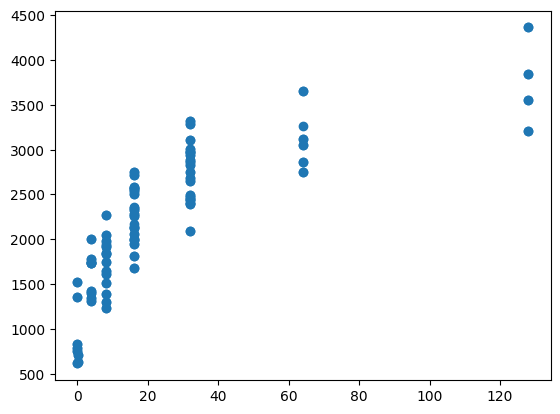

ram


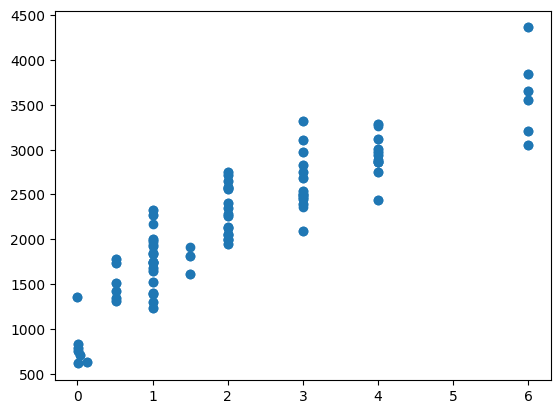

RearCam


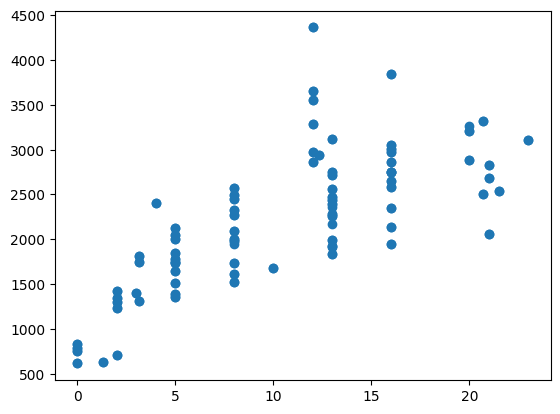

Front_Cam


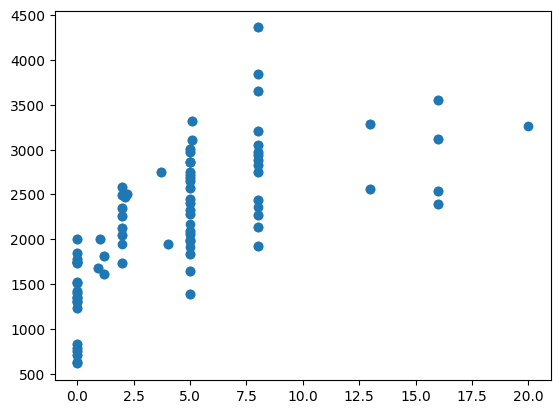

battery


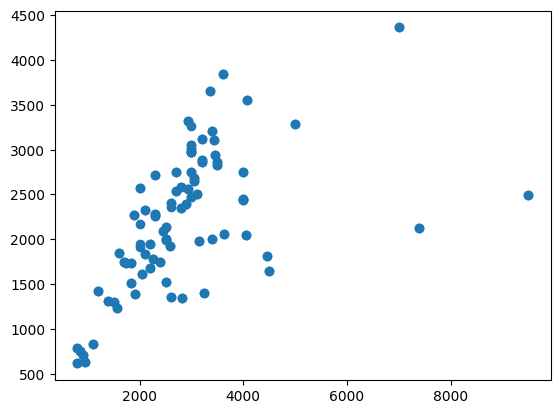

thickness


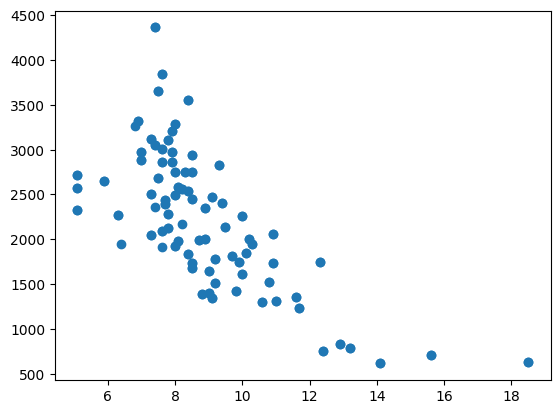

In [54]:
for c in data.columns:
    if c != 'Price':
        print(c)
        plt.scatter(data[c], data['Price'])
        plt.show()

 #sale и product id никак не коррелирует

In [55]:
data.drop(['Product_id', 'Sale'], axis = 1, inplace=True)
data.head(10)

,Price,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,2357,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,1749,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,1916,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,1315,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,1749,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
5,2137,150.0,5.5,401,4,2.30,16.0,2.000,16.00,8.0,2500,9.5
6,1238,134.1,4.0,233,2,1.20,8.0,1.000,2.00,0.0,1560,11.7
7,2137,150.0,5.5,401,4,2.30,16.0,2.000,16.00,8.0,2500,9.5
8,1315,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
9,2580,145.0,5.1,432,4,2.50,16.0,2.000,16.00,2.0,2800,8.1


In [56]:
y = data['Price']
X = data.drop('Price', axis=1)

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

model = LinearRegression()
model.fit(Xtrain, ytrain) # обучение модели
pred_train = model.predict(Xtrain)
pred_test = model.predict(Xtest)

In [72]:
r2_score(ytrain, pred_train), r2_score(ytest, pred_test)

(0.9507221541430266, 0.9587980295092361)

In [73]:
mean_squared_error(ytrain,pred_train), mean_squared_error(ytest,pred_test)

(29132.499429747775, 23356.94509808319)

In [58]:
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(model.coef_))], axis = 1)
coefficients

,0,0
0,weight,-73.915496
1,resoloution,-80.952521
2,ppi,157.438439
3,cpu core,124.847699
4,cpu freq,74.331267
5,internal mem,141.157136
6,ram,175.901384
7,RearCam,12.236506
8,Front_Cam,17.610780
9,battery,178.642682


In [59]:
from sklearn.linear_model import LassoCV

n_alphas = 200
alphas = np.linspace(0.1, 100, n_alphas)

lasso_cv = LassoCV(alphas=alphas, 
                   cv=3, random_state=10)
lasso_cv.fit(X, y)

LassoCV(alphas=array([  0.1       ,   0.60201005,   1.1040201 ,   1.60603015,
         2.1080402 ,   2.61005025,   3.1120603 ,   3.61407035,
         4.1160804 ,   4.61809045,   5.1201005 ,   5.62211055,
         6.1241206 ,   6.62613065,   7.1281407 ,   7.63015075,
         8.1321608 ,   8.63417085,   9.1361809 ,   9.63819095,
        10.14020101,  10.64221106,  11.14422111,  11.64623116,
        12.14824121,  12.65025126,  13.15226131,  13.65427136,
        14.15628141,  14.65829146,  15.1...
        84.43768844,  84.93969849,  85.44170854,  85.94371859,
        86.44572864,  86.94773869,  87.44974874,  87.95175879,
        88.45376884,  88.95577889,  89.45778894,  89.95979899,
        90.46180905,  90.9638191 ,  91.46582915,  91.9678392 ,
        92.46984925,  92.9718593 ,  93.47386935,  93.9758794 ,
        94.47788945,  94.9798995 ,  95.48190955,  95.9839196 ,
        96.48592965,  96.9879397 ,  97.48994975,  97.9919598 ,
        98.49396985,  98.9959799 ,  99.49798995, 100.        ]),
        cv=3, random_state=10)

In [60]:
regressor2 = Lasso(alpha=lasso_cv.alpha_)

regressor2.fit(Xtrain, ytrain)

ypred2_train = regressor2.predict(Xtrain)
ypred2_test = regressor2.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred2_train), r2_score(ytest,ypred2_test), mean_squared_error(ytrain,ypred2_train), mean_squared_error(ytest,ypred2_test))

Scores: 0.9472554287458067 0.9497559024729212 31181.9878743265 28482.82772557662


In [74]:
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(regressor2.coef_))], axis = 1)
coefficients

,0,0
0,weight,-43.769905
1,resoloution,-0.000000
2,ppi,172.303115
3,cpu core,128.922962
4,cpu freq,50.720058
5,internal mem,135.594725
6,ram,216.978670
7,RearCam,1.621333
8,Front_Cam,17.275083
9,battery,74.918149


# Задание 2. 

Поработайте с датасетом diet_data (Его создатель решил похудеть, подсчитывая калории, и ему это действительно удалось; в течение времени, пока худел, он записывал, что и какое он ест). Целевая колонка - change. 

In [118]:
data2 = pd.read_csv('diet_data.csv')
data2.head()

,Date,Stone,Pounds,Ounces,weight_oz,calories,cals_per_oz,five_donuts,walk,run,wine,prot,weight,change
0,7/30/2018,12.0,2.0,6.0,2726.0,1950.0,0.72,1.0,1.0,0.0,0.0,0.0,0.0,-30.0
1,7/31/2018,12.0,0.0,8.0,2696.0,2600.0,0.96,1.0,0.0,0.0,0.0,0.0,0.0,8.0
2,8/1/2018,12.0,1.0,0.0,2704.0,2500.0,0.92,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,8/2/2018,12.0,1.0,0.0,2704.0,1850.0,0.68,1.0,1.0,0.0,1.0,0.0,0.0,-40.0
4,8/3/2018,11.0,12.0,8.0,2664.0,2900.0,1.09,1.0,1.0,0.0,0.0,0.0,0.0,14.0


In [119]:
data2.dtypes

Date            object
Stone          float64
Pounds         float64
Ounces         float64
weight_oz      float64
calories       float64
cals_per_oz     object
five_donuts    float64
walk           float64
run            float64
wine           float64
prot           float64
weight         float64
change         float64
dtype: object

In [120]:
data2.set_index('Date', inplace=True)

In [121]:
data2.dropna(how='any', inplace=True)
data2.drop(['Stone', 'Pounds', 'Ounces'], axis = 1, inplace=True) #эти три колонки - все равно что вес в унциях в weight_oz
data2['cals_per_oz'] = data2['cals_per_oz'].apply(float)

In [122]:
data2.isna().any()

weight_oz      False
calories       False
cals_per_oz    False
five_donuts    False
walk           False
run            False
wine           False
prot           False
weight         False
change         False
dtype: bool

weight_oz


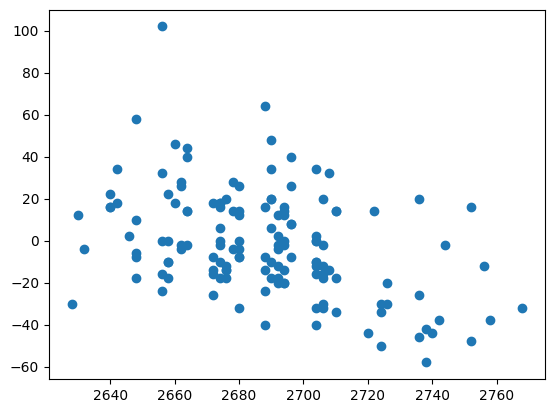

calories


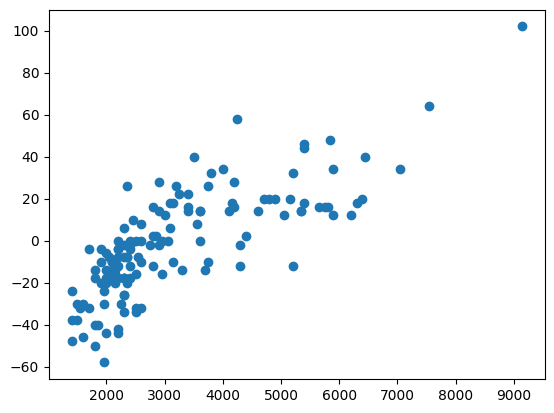

cals_per_oz


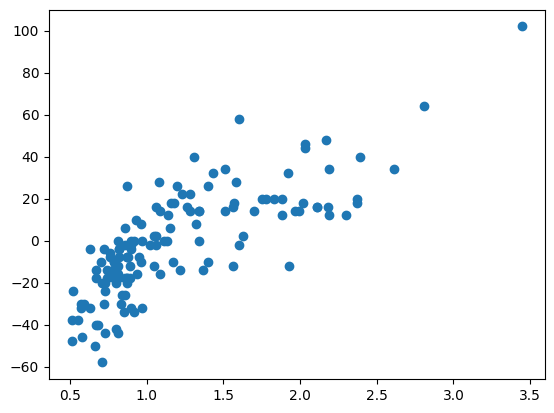

five_donuts


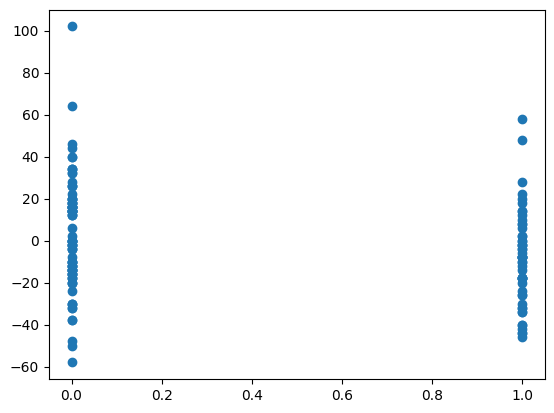

walk


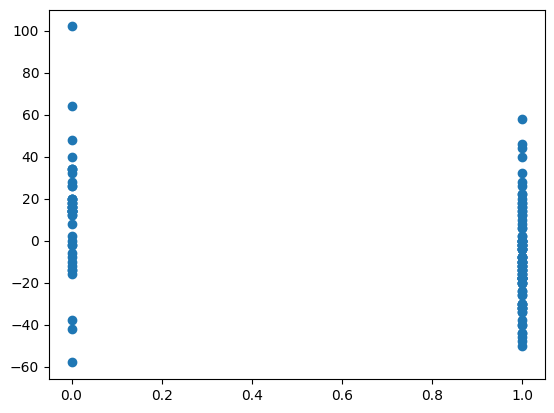

run


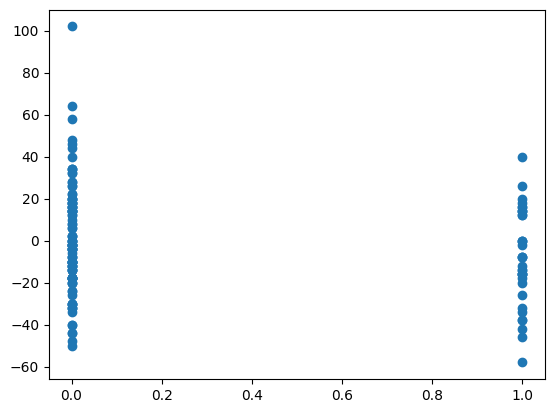

wine


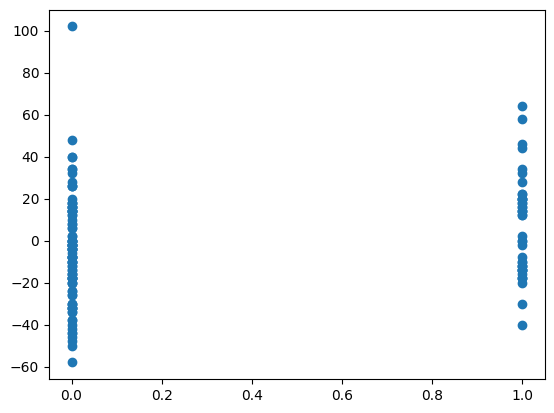

prot


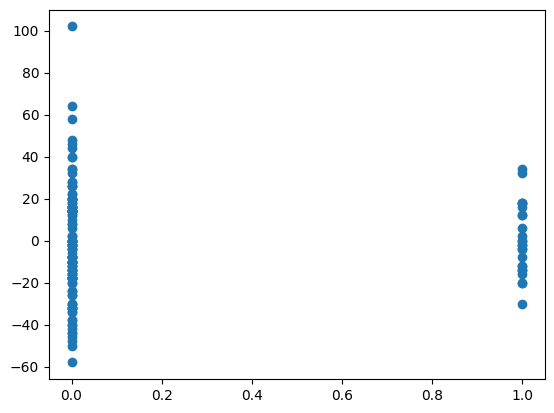

weight


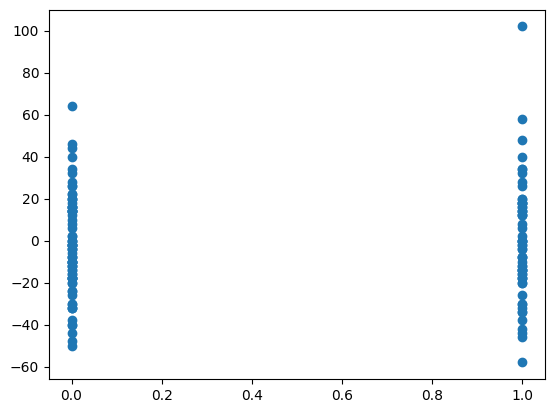

In [123]:
for c in data2.columns:
    if c != 'change':
        print(c)
        plt.scatter(data2[c], data2['change'])
        plt.show()

In [124]:
y = data2['change']
X = data2.drop('change', axis=1)

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [125]:
n_alphas = 200
alphas = np.linspace(0.1, 100, n_alphas)

lasso_cv = LassoCV(alphas=alphas, 
                   cv=3, random_state=10)
lasso_cv.fit(X, y)

LassoCV(alphas=array([  0.1       ,   0.60201005,   1.1040201 ,   1.60603015,
         2.1080402 ,   2.61005025,   3.1120603 ,   3.61407035,
         4.1160804 ,   4.61809045,   5.1201005 ,   5.62211055,
         6.1241206 ,   6.62613065,   7.1281407 ,   7.63015075,
         8.1321608 ,   8.63417085,   9.1361809 ,   9.63819095,
        10.14020101,  10.64221106,  11.14422111,  11.64623116,
        12.14824121,  12.65025126,  13.15226131,  13.65427136,
        14.15628141,  14.65829146,  15.1...
        84.43768844,  84.93969849,  85.44170854,  85.94371859,
        86.44572864,  86.94773869,  87.44974874,  87.95175879,
        88.45376884,  88.95577889,  89.45778894,  89.95979899,
        90.46180905,  90.9638191 ,  91.46582915,  91.9678392 ,
        92.46984925,  92.9718593 ,  93.47386935,  93.9758794 ,
        94.47788945,  94.9798995 ,  95.48190955,  95.9839196 ,
        96.48592965,  96.9879397 ,  97.48994975,  97.9919598 ,
        98.49396985,  98.9959799 ,  99.49798995, 100.        ]),
        cv=3, random_state=10)

In [126]:
regressor2 = Lasso(alpha=lasso_cv.alpha_)

regressor2.fit(Xtrain, ytrain)

ypred2_train = regressor2.predict(Xtrain)
ypred2_test = regressor2.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred2_train), r2_score(ytest,ypred2_test), mean_squared_error(ytrain,ypred2_train) ** 0.5, mean_squared_error(ytest,ypred2_test) ** 0.5)

Scores: 0.7713940726799059 0.6117201068493001 12.261257313173145 12.56658185028873


In [127]:
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(model.coef_))], axis = 1)
coefficients

,0,0
0,weight_oz,-73.915496
1,calories,-80.952521
2,cals_per_oz,157.438439
3,five_donuts,124.847699
4,walk,74.331267
5,run,141.157136
6,wine,175.901384
7,prot,12.236506
8,weight,17.610780
9,NaN,178.642682


# Задание 3. 

Поработайте с датасетом Life Expectancy. Целевая колонка - Life Expectancy, собственно. 

In [128]:
data3 = pd.read_csv('Life Expectancy Data.csv')
data3

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [129]:
data3.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [130]:
data3['Status'].unique()

array(['Developing', 'Developed'], dtype=object)

In [131]:
data3.dropna(how='any', inplace=True)
data3.drop(['Country', 'Year'], axis=1, inplace=True)
data3['Status'] = data3['Status'].apply(lambda x: 1 if 'Developed' else 0)
data3

,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,1,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,42,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,1,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,41,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,1,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,40,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,1,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,39,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [132]:
y = data3['Life expectancy ']
X = data3.drop('Life expectancy ', axis=1)

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [133]:
n_alphas = 200
alphas = np.linspace(0.1, 100, n_alphas)

lasso_cv = LassoCV(alphas=alphas, 
                   cv=3, random_state=10)
lasso_cv.fit(X, y)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 84.12037819006582, tolerance: 8.403631042766156
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1247.25969494343, tolerance: 8.403631042766156
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1447.3530019191548, tolerance: 8.403631042766156
  model = cd_fast.enet_coordina

LassoCV(alphas=array([  0.1       ,   0.60201005,   1.1040201 ,   1.60603015,
         2.1080402 ,   2.61005025,   3.1120603 ,   3.61407035,
         4.1160804 ,   4.61809045,   5.1201005 ,   5.62211055,
         6.1241206 ,   6.62613065,   7.1281407 ,   7.63015075,
         8.1321608 ,   8.63417085,   9.1361809 ,   9.63819095,
        10.14020101,  10.64221106,  11.14422111,  11.64623116,
        12.14824121,  12.65025126,  13.15226131,  13.65427136,
        14.15628141,  14.65829146,  15.1...
        84.43768844,  84.93969849,  85.44170854,  85.94371859,
        86.44572864,  86.94773869,  87.44974874,  87.95175879,
        88.45376884,  88.95577889,  89.45778894,  89.95979899,
        90.46180905,  90.9638191 ,  91.46582915,  91.9678392 ,
        92.46984925,  92.9718593 ,  93.47386935,  93.9758794 ,
        94.47788945,  94.9798995 ,  95.48190955,  95.9839196 ,
        96.48592965,  96.9879397 ,  97.48994975,  97.9919598 ,
        98.49396985,  98.9959799 ,  99.49798995, 100.        ]),
        cv=3, random_state=10)

In [134]:
regressor2 = Lasso(alpha=lasso_cv.alpha_)

regressor2.fit(Xtrain, ytrain)

ypred2_train = regressor2.predict(Xtrain)
ypred2_test = regressor2.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred2_train), r2_score(ytest,ypred2_test), mean_squared_error(ytrain,ypred2_train) ** 0.5, mean_squared_error(ytest,ypred2_test) ** 0.5)

Scores: 0.8140681748878839 0.7845375864322802 3.827662562713503 3.9118634848227987


In [135]:
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(regressor2.coef_))], axis = 1)
coefficients

,0,0
0,Status,0.000000
1,Adult Mortality,-2.231258
2,infant deaths,-0.000000
3,Alcohol,0.000000
4,percentage expenditure,0.311051
5,Hepatitis B,0.000000
6,Measles,-0.000000
7,BMI,0.369155
8,under-five deaths,-0.000000
9,Polio,0.000000
